# Loss Functions: How a Model Learns from Its Mistakes

Imagine a model is a student answering questions. The **loss function** is the marking rule: it compares an answer with the correct answer and gives the model a number describing how wrong it was. A smaller loss means a better prediction. During training, the model adjusts its settings to make the loss smaller.

This notebook explains the idea from the beginning, works through the arithmetic, and shows when to use four regression losses and two families of classification losses. The chart in the next cell is generated by Python; run that cell to see how the penalties change as predictions change.

## Contents

1. [The basic idea](#the-basic-idea)
2. [Regression losses](#regression-losses)
   - [Mean Squared Error (MSE)](#1-mean-squared-error-mse)
   - [Mean Absolute Error (MAE)](#2-mean-absolute-error-mae)
   - [Huber loss](#3-huber-loss)
   - [Mean Squared Logarithmic Error (MSLE)](#4-mean-squared-logarithmic-error-msle)
3. [Classification losses](#classification-losses)
   - [Binary cross-entropy](#1-binary-cross-entropy-bce)
   - [Categorical cross-entropy](#2-categorical-cross-entropy)
4. [Choosing a loss and avoiding mistakes](#choosing-a-loss-and-avoiding-mistakes)
5. [Quick review and practice](#quick-review-and-practice)

## The basic idea

### What is a loss function?

A loss function is a rule that turns a prediction and its known correct answer into a number. For one example, write:

- $y$: the true answer (also called the target or label)
- $\hat{y}$: the model's prediction (read this as “y-hat”)
- $L(y, \hat{y})$: the loss for this one example

For example, if the true house price is $300,000 and the model predicts $280,000, the model has made an error. A loss function decides how large a penalty that error receives. Different loss functions mark the same mistake differently.

A loss is not usually a percentage, and its size has meaning only in the context of the chosen loss and data. A loss of 5 is not automatically “5% wrong.” **Lower is better**, and zero usually means a perfect prediction for the examples being measured.

### Loss, batch loss, and cost

A **per-example loss** scores one example. Training usually uses a group of examples called a **batch**. The batch's mean loss is the average of its examples:

$$
J_{\text{batch}} = \frac{1}{m} \sum_{i=1}^{m} L(y_i, \hat{y}_i)
$$

Here, $m$ is the number of examples in the batch. Some books call this average the **cost** or **objective**; other books use “loss” for both the individual score and the batch average. Check the definition being used.

When $m=1$, the batch mean is just that one example's loss. When $m>1$, we commonly average the individual losses to get one number for the batch. We do **not** need a different kind of formula just because there is more than one example. A sum can also be used, but its value grows with batch size, so the mean is common and makes runs with different batch sizes easier to compare.

### What does “error” mean?

For a numeric prediction, the **residual** is often defined as:

$$
e = \hat{y} - y
$$

- $e=0$: exact prediction.
- $e>0$: prediction is too high.
- $e<0$: prediction is too low.

The sign tells the direction; many loss functions use the size of the error so that over-prediction and under-prediction are both penalized. The plot below calls this horizontal value “prediction - true value.”

### Regression and classification are different jobs

- **Regression** predicts a number, such as a temperature, travel time, or house price. Its target can take many numeric values.
- **Classification** predicts a category, such as cat/dog or spam/not spam. A classifier may produce probabilities that describe how sure it is about each category.

Use a loss that matches the kind of answer and the model's output. The wrong pairing can produce confusing results or an error during training.

## Regression losses

Regression losses compare numeric predictions with numeric targets. The four losses below are built from different ideas about what counts as a big mistake.

### 1. Mean Squared Error (MSE)

**Idea:** square each prediction error, then average the squares. Squaring removes the minus sign and makes large mistakes count much more than small ones.

For one example:

$$
L_{\text{MSE}}(y, \hat{y}) = (y - \hat{y})^2
$$

For $m$ examples in a batch:

$$
J_{\text{MSE}} = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2
$$

If the batch has one example, its loss is $(y-\\hat{y})^2$. With a batch of several examples, calculate a squared error for each one and take their mean. Some contexts use the **sum of squared errors** instead; that is a sum, not a mean, and will be larger for a bigger batch.

**Worked example:** true values are $[3, 5, 2]$ and predictions are $[4, 3, 5]$. The errors (prediction minus truth) are $[1, -2, 3]$. Squaring gives $[1, 4, 9]$, so:

$$
J_{\text{MSE}} = (1+4+9)/3 = 14/3 \approx 4.67
$$

The units are squared. If the target is measured in dollars, the MSE is measured in dollars squared; that can make it less intuitive to explain directly.

**Why use it?** MSE is smooth and easy for many optimization methods to work with. It strongly discourages large errors, so it is useful when large misses are especially costly and the data do not contain troublesome outliers.

**Limitations:** squaring makes outliers very influential. One unusually large mistake can dominate the batch. The result is also in squared target units, and the average prediction that minimizes MSE can be pulled toward extreme values.

### 2. Mean Absolute Error (MAE)

**Idea:** take the absolute size of each error, then average. Absolute value changes a negative error into a positive size but does not square it.

For one example and a batch:

$$
L_{\text{MAE}}(y, \hat{y}) = |y - \hat{y}|, \\qquad
J_{\text{MAE}} = \frac{1}{m} \sum_{i=1}^{m} |y_i - \hat{y}_i|
$$

Using the same errors $[1,-2,3]$, their absolute sizes are $[1,2,3]$. Therefore:

$$
J_{\text{MAE}} = (1+2+3)/3 = 2
$$

MAE is in the same units as the target, so an MAE of 2 means an average absolute miss of 2 target-units on the measured examples.

**Why use it?** MAE is easier to interpret and is less affected by a very large error than MSE. It is a sensible choice when a typical error matters and extreme errors should not dominate the score.

**Limitations:** it gives equal slope-sized penalties to errors as they grow, so it does not emphasize large misses as strongly as MSE. The absolute-value graph has a sharp corner at zero; the loss is not differentiable at exactly zero. Optimization libraries handle this, but the corner is one reason smoother alternatives are sometimes chosen.

### 3. Huber loss

**Idea:** Huber loss combines MSE-like behavior near a correct prediction with MAE-like behavior for large errors. The parameter $\\delta$ sets the boundary between the two regions.

For residual $e=\hat{y}-y$:

$$
L_{\text{Huber}}(e) =
\begin{cases}
\frac{1}{2}e^2, & |e| \\le \\delta \\\\
\delta\\left(|e|-\frac{1}{2}\\delta\\right), & |e| > \\delta
\end{cases}
$$

The batch loss is the mean of those per-example values. Many libraries use this convention, though some scale the formula differently. Always check the library's definition if exact numeric values matter.

With $\delta=1$ and errors $[1,-2,3]$, the losses are $[0.5,1.5,2.5]$, whose mean is $1.5$. For small errors, the curve is smooth and quadratic. Past $\\delta$, it grows linearly, so an enormous error does not overwhelm the score as quickly as it can with MSE.

**Why use it?** It is a useful compromise when the data have some outliers: it is smooth around zero like MSE but more robust to large residuals like MAE.

**Limitations:** you must choose $\\delta$, and its useful scale depends on the scale and units of the target. A value that is too small or too large changes which examples use each part of the formula. Huber loss does not remove outliers; it just reduces their influence compared with MSE.

### 4. Mean Squared Logarithmic Error (MSLE)

**Idea:** compare logarithms of the true and predicted values instead of comparing their raw difference. This makes the loss care more about relative or proportional differences than equal-sized absolute differences.

$$
J_{\text{MSLE}} = \frac{1}{m} \sum_{i=1}^{m}\left[\log(1+y_i)-\log(1+\hat{y}_i)\right]^2
$$

The $+1$ allows a value of zero because $\\log(1)=0$. In common use, both targets and predictions must be non-negative; a prediction less than zero makes $\\log(1+\\hat{y})$ invalid. If your model can predict negative values, use an output design or a different loss that matches the problem rather than silently passing invalid values into the logarithm.

**Worked intuition:** being off by 1 when the true value is 10 is a much larger proportional mistake than being off by 1 when the true value is 100. MSLE reflects this: $|\\log(11)-\\log(10)| \\approx 0.095$, while $|\\log(101)-\\log(100)| \\approx 0.010$. It does not treat those two raw errors as equally important.

**Why use it?** It can suit non-negative targets that span a wide range, such as counts or quantities where proportional error matters more than raw error. It reduces the influence of very large target values compared with raw squared error.

**Limitations:** it is unsuitable for negative targets or predictions and can be confusing to interpret because it compares logged values. It is not automatically the right choice for every skewed dataset. If being wrong by 5 units matters equally everywhere, MAE or MSE may better match the real goal.

## Classification losses

A classifier often gives a probability for each possible class. A probability is between 0 and 1, and the probabilities for a single-choice multiclass problem add to 1. The loss should reward high probability for the correct answer and penalize confident probability assigned to the wrong answer.

### 1. Binary cross-entropy (BCE)

**Use it for:** one yes/no decision, such as spam/not spam, sick/not sick, or cat/not cat. Write the true label as $y \\in \\{0,1\\}$ and the model's predicted probability for class 1 as $p \\in [0,1]$.

For one example:

$$
L_{\text{BCE}}(y,p) = -\left[y\log(p)+(1-y)\log(1-p)\right]
$$

For a batch, average the example losses:

$$
J_{\text{BCE}} = -\frac{1}{m} \sum_{i=1}^{m}
\left[y_i\log(p_i)+(1-y_i)\log(1-p_i)\right]
$$

The formula has a simple switch:

- If $y=1$, the loss becomes $-\log(p)$. The model wants $p$ close to 1.
- If $y=0$, the loss becomes $-\log(1-p)$. The model wants $p$ close to 0.

**Worked example:** for a true class of 1 and prediction $p=0.9$, loss is $-\\log(0.9) \\approx 0.105$, a small penalty. If the model instead says $p=0.1$, loss is $-\\log(0.1) \\approx 2.303$, a much larger penalty. A confident wrong guess is costly; a confident correct guess has a small loss.

For true class 0, the pattern flips: predicting $p=0.1$ gives about $0.105$, while predicting $p=0.9$ gives about $2.303$. The right-hand graph in the plotting cell shows both cases.

**When to use it:** use BCE for a single binary output. It is also commonly used for **multilabel** tasks, where several labels can independently be true at once, by applying one binary decision per label. In a multilabel task, several probabilities can be high together; this differs from a single-choice multiclass task.

**Advantages:** it uses the confidence of the prediction, provides a strong penalty for confidently wrong predictions, and works naturally with probability outputs.

**Limitations and care:** labels should represent 0/1 targets, and the model output must be paired correctly with the loss. Probabilities exactly 0 or 1 can cause logarithms of zero in the written formula, so software implementations use numerically stable calculations. For neural networks, a common, stable setup is to give the loss the raw output scores called **logits** and let the loss internally handle the sigmoid and logarithms. Do not apply sigmoid yourself if the selected loss expects logits.

### 2. Categorical cross-entropy

“Classification cross-entropy” can mean several things. Here, **categorical cross-entropy** means the standard loss for a **single-choice problem with three or more classes**: choose exactly one class, such as apple, banana, or orange.

Suppose there are $K$ classes. Let $y_k$ be 1 for the correct class and 0 for the others (a **one-hot** target), and let $p_k$ be the model's predicted probability for class $k$. Then:

$$
L_{\text{categorical}} = -\sum_{k=1}^{K} y_k \log(p_k)
$$

Because only the correct class has $y_k=1$, this simplifies to:

$$
L_{\text{categorical}} = -\log(p_{\text{correct}})
$$

**Worked example:** the classes are cat, dog, and bird. The correct answer is dog, represented by $[0,1,0]$. If the predicted probabilities are $[0.1,0.7,0.2]$, the loss is $-\\log(0.7) \\approx 0.357$. The model assigned 70% probability to the correct class. If it gave dog only 0.05 probability, the loss would be $-\\log(0.05) \\approx 2.996$.

**One-hot vs sparse categorical cross-entropy:** they express the same goal but encode the answer differently:

- **Categorical cross-entropy** commonly expects a one-hot vector, such as dog = $[0,1,0]$.
- **Sparse categorical cross-entropy** commonly expects the class number, such as dog = `1`.

The word “sparse” refers to storing one class index instead of a mostly-zero vector. It does not mean the loss is weaker or approximate. Check the exact label format and output requirements in your library; the two variants are not interchangeable without matching the target representation.

**How probabilities are made:** for mutually exclusive classes, a model commonly produces one raw score (logit) per class. A **softmax** operation turns the scores into probabilities that add to 1. Many libraries provide a categorical cross-entropy option that accepts logits directly for numerical stability. Match the loss setting to whether your model returns probabilities or logits; do not apply softmax twice.

**Advantages:** the loss uses all class probabilities and penalizes the model for placing too little probability on the correct class. It is the standard starting point for single-choice multiclass classification.

**Limitations and care:** ordinary categorical cross-entropy assumes one correct class per example. It is not the default for multilabel problems where multiple classes may be true at once; use an independent binary loss for that setup. Very imbalanced classes, noisy labels, and poorly calibrated probabilities can also make training challenging; the loss does not automatically fix those issues.

## Choosing a loss and avoiding mistakes

| Problem and priority | A reasonable starting point | Remember |
|---|---|---|
| Numeric target; large errors deserve a much bigger penalty | MSE | Outliers can dominate; result is in squared units. |
| Numeric target; typical absolute miss is what matters | MAE | Same units as the target; less sensitive to outliers. |
| Numeric target; want a smooth loss that is less sensitive to outliers | Huber | Choose a useful $\\delta$ for the target scale. |
| Non-negative target; proportional errors matter | MSLE | Targets and predictions must be non-negative. |
| One yes/no label | Binary cross-entropy | Use a single binary probability, or a logits-compatible BCE. |
| Exactly one choice from several classes | Categorical or sparse categorical cross-entropy | Choose one-hot or class-index targets to match the loss. |
| Several independent labels can all be true | Binary cross-entropy per label | This is multilabel, not single-choice multiclass. |

Before training, check these questions:

1. Is the target a number, a yes/no answer, one of many classes, or several independent labels?
2. Does the model output a number, probabilities, or logits?
3. Does this loss expect probabilities or logits, and what shape/encoding should labels have?
4. Should large errors receive a much larger penalty, or should the score be robust to outliers?
5. Is the batch loss a mean or a sum? Is that convention consistent when comparing runs?

Common mistakes to avoid:

- **Using a regression loss for class IDs:** class numbers such as 0, 1, and 2 are names, not measurements; predicting 2 is not necessarily “twice” class 1.
- **Confusing multiclass with multilabel:** single-choice classes usually use softmax with categorical cross-entropy; independent labels usually use sigmoid/BCE per label.
- **Mixing probabilities and logits:** this can cause incorrect values or unstable training. Read the loss function's input expectations.
- **Mixing up mean and sum:** a sum changes with batch size even if average prediction quality stays the same.
- **Thinking a low training loss proves a model is good:** evaluate on separate validation/test examples and use task-relevant metrics too. Loss guides learning; accuracy, MAE, or another metric may be easier to communicate.
- **Choosing a loss only because it is popular:** the loss should reflect what kinds of mistakes matter in the real problem.

## Quick review and practice

### The whole story in six lines

- A loss function scores how wrong a prediction is; training tries to make that score smaller.
- Per-example loss scores one item; batch loss commonly averages the individual scores.
- MSE squares errors, so big misses count much more.
- MAE uses absolute error, so it is easier to interpret and less affected by outliers.
- Huber is quadratic near zero and linear for large errors; MSLE compares logged non-negative values.
- BCE is for binary or independent labels; categorical cross-entropy is for one correct class among many.

### Practice questions

1. A true value is 8 and the prediction is 5. What are the residual, squared error, and absolute error?
2. Which is more affected by one huge outlier: MSE or MAE? Why?
3. A target is 0/1 and the model predicts a probability for class 1. Which loss family is a natural starting point?
4. A picture must be classified as exactly one of 12 animal types. Would you usually choose binary cross-entropy for one output, or categorical cross-entropy across the 12 choices?
5. A product count can never be negative, ranges from 0 to 100,000, and proportional mistakes matter. Which regression loss might be worth trying, and what input restriction must be checked?

### Answers

1. Residual $=5-8=-3$; squared error $=(-3)^2=9$; absolute error $=|-3|=3$.
2. MSE, because squaring makes a large error grow much faster than a small one.
3. Binary cross-entropy, with the model output and loss configured consistently for probabilities or logits.
4. Categorical cross-entropy (or sparse categorical cross-entropy if labels are stored as class indices), because exactly one of the 12 classes is correct.
5. MSLE may be worth trying because proportional mistakes matter, but both targets and predictions must be non-negative.

### Tiny glossary

- **Target / label:** the known correct answer used for training or evaluation.
- **Prediction:** the answer produced by the model.
- **Residual:** prediction minus true numeric value.
- **Batch:** the group of examples processed together in one training step.
- **Outlier:** a value far from most of the data.
- **Logit:** a raw model score before converting it into a probability.
- **Epoch:** one pass through all training examples.


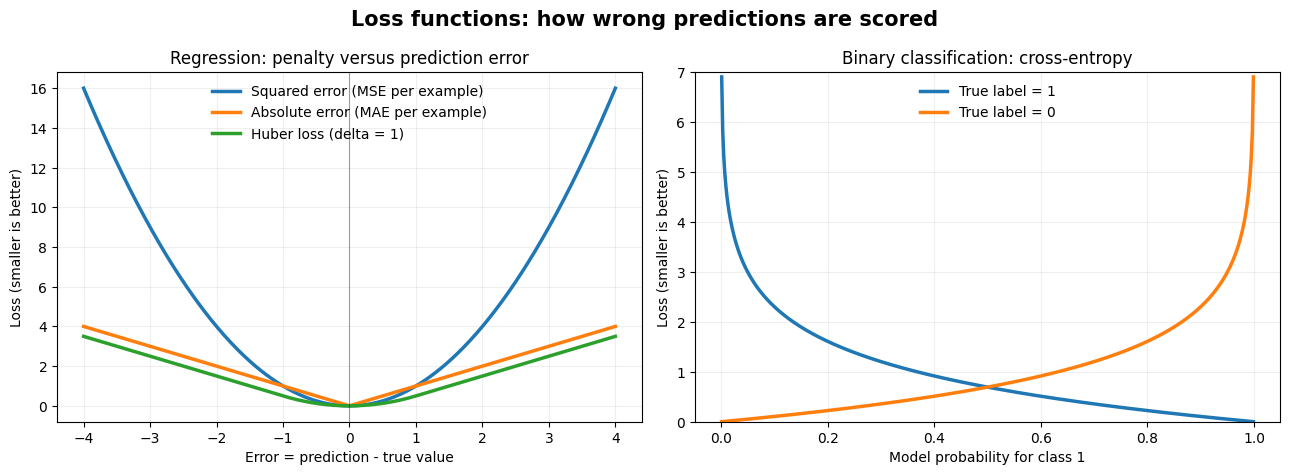

In [2]:
import numpy as np
import matplotlib.pyplot as plt

errors = np.linspace(-4, 4, 500)
absolute_errors = np.abs(errors)
mse = errors**2
mae = absolute_errors
huber_delta = 1.0
huber = np.where(
    absolute_errors <= huber_delta,
    0.5 * errors**2,
    huber_delta * (absolute_errors - 0.5 * huber_delta),
)

probabilities = np.linspace(0.001, 0.999, 500)
bce_true_one = -np.log(probabilities)
bce_true_zero = -np.log(1 - probabilities)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
fig.suptitle("Loss functions: how wrong predictions are scored", fontsize=15, weight="bold")

axes[0].plot(errors, mse, label="Squared error (MSE per example)", linewidth=2.5)
axes[0].plot(errors, mae, label="Absolute error (MAE per example)", linewidth=2.5)
axes[0].plot(errors, huber, label="Huber loss (delta = 1)", linewidth=2.5)
axes[0].axvline(0, color="black", linewidth=0.8, alpha=0.35)
axes[0].set(title="Regression: penalty versus prediction error", xlabel="Error = prediction - true value", ylabel="Loss (smaller is better)")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.2)

axes[1].plot(probabilities, bce_true_one, label="True label = 1", linewidth=2.5)
axes[1].plot(probabilities, bce_true_zero, label="True label = 0", linewidth=2.5)
axes[1].set(title="Binary classification: cross-entropy", xlabel="Model probability for class 1", ylabel="Loss (smaller is better)", ylim=(0, 7))
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.2)

fig.tight_layout()
plt.show()